#CNN MNIST - Desenvolvimento Completo



###Importações

In [ ]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

torch.manual_seed(123)
print('PyTorch version:', torch.__version__)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Device:', device)

PyTorch version: 2.10.0+cu128
Device: cuda


##Baseline para avaliação

O Baseline será nossa Rede Neural padrão desenvolvida para o dataset MNIST, que servirá de avaliação base dentro dos estudos que faremos nesta arquitetura

In [ ]:
transform = transforms.ToTensor()
train = datasets.MNIST(root='.', train=True,  download=True, transform=transform)
test  = datasets.MNIST(root='.', train=False, download=True, transform=transform)

train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader  = DataLoader(test,  batch_size=128)

print(f'Treino: {len(train)} imagens | Teste: {len(test)} imagens')

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]

Treino: 60000 imagens | Teste: 10000 imagens


In [ ]:
len(train_loader)

469

In [ ]:
print(train[0][0].shape)

torch.Size([1, 28, 28])


In [ ]:
print(train[0][1])

5


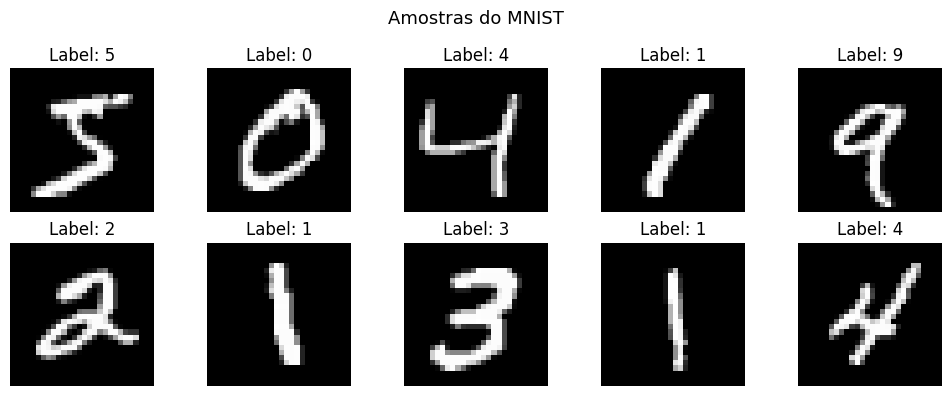

In [ ]:
# Visualização rápida de 10 exemplos do dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    img, label = train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Amostras do MNIST', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
class Baseline3x3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, (3, 3))
        self.conv2 = nn.Conv2d(32, 32, (3, 3))
        self.activation = nn.ReLU()
        self.bnorm1 = nn.BatchNorm2d(32)
        self.bnorm2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d((2, 2))
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(32 * 5 * 5, 128)
        self.linear2 = nn.Linear(128, 128)
        self.output  = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, X):
        X = self.pool(self.bnorm1(self.activation(self.conv1(X))))
        X = self.pool(self.bnorm2(self.activation(self.conv2(X))))
        X = self.flatten(X)
        X = self.dropout(self.activation(self.linear1(X)))
        X = self.dropout(self.activation(self.linear2(X)))
        return self.output(X)


In [ ]:
# Função para treinamento

def train_model(net, train_loader, test_loader, epochs = 5):
  net.to(device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(net.parameters())

  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

  for epoch in range(epochs):
    net.train()
    running_loss, running_acc = 0., 0.
    for inputs, labels in train_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
      preds = outputs.argmax(dim = 1)
      running_acc += (preds == labels).float().mean().item()

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)

    net.eval()
    val_loss, val_acc = 0., 0.
    with torch.no_grad():
      for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        val_loss += criterion(outputs, labels).item()
        preds = outputs.argmax(dim=1)
        val_acc += (preds == labels).float().mean().item()

    val_loss =  val_loss / len(test_loader)
    val_acc = val_acc / len(test_loader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Época {epoch+1:2d}/{epochs} | '
              f'Loss Treino: {train_loss:.4f} | Acc Treino: {train_acc:.4f} | '
              f'Loss Val: {val_loss:.4f} | Acc Val: {val_acc:.4f}')

  return history






In [ ]:
#Treinar a rede Baseline

net_baseline = Baseline3x3()
history_baseline = train_model(net_baseline, train_loader, test_loader, epochs=5)

Época  1/5 | Loss Treino: 0.1649 | Acc Treino: 0.9520 | Loss Val: 0.0460 | Acc Val: 0.9859
Época  2/5 | Loss Treino: 0.0488 | Acc Treino: 0.9850 | Loss Val: 0.0316 | Acc Val: 0.9898
Época  3/5 | Loss Treino: 0.0343 | Acc Treino: 0.9895 | Loss Val: 0.0258 | Acc Val: 0.9915
Época  4/5 | Loss Treino: 0.0272 | Acc Treino: 0.9913 | Loss Val: 0.0384 | Acc Val: 0.9886
Época  5/5 | Loss Treino: 0.0226 | Acc Treino: 0.9931 | Loss Val: 0.0296 | Acc Val: 0.9910


## Criação da Rede com filtro de 5X5


In [ ]:


class Filtro5x5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, (5, 5))
        self.conv2 = nn.Conv2d(32, 32, (5, 5))
        self.activation = nn.ReLU()
        self.bnorm1 = nn.BatchNorm2d(32)  # BN separado para cada estágio
        self.bnorm2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d((2, 2))
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(32 * 4 * 4, 128)
        self.linear2 = nn.Linear(128, 128)
        self.output  = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, X):
        X = self.pool(self.bnorm1(self.activation(self.conv1(X))))
        X = self.pool(self.bnorm2(self.activation(self.conv2(X))))
        X = self.flatten(X)
        X = self.dropout(self.activation(self.linear1(X)))
        X = self.dropout(self.activation(self.linear2(X)))
        return self.output(X)


In [ ]:
print('=== FILTRO 5×5 ===')
net_5x5 = Filtro5x5()
history_5x5 = train_model(net_5x5, train_loader, test_loader, epochs=5)

=== FILTRO 5×5 ===
Época  1/5 | Loss Treino: 0.1475 | Acc Treino: 0.9574 | Loss Val: 0.0345 | Acc Val: 0.9884
Época  2/5 | Loss Treino: 0.0403 | Acc Treino: 0.9881 | Loss Val: 0.0278 | Acc Val: 0.9917
Época  3/5 | Loss Treino: 0.0287 | Acc Treino: 0.9914 | Loss Val: 0.0314 | Acc Val: 0.9903
Época  4/5 | Loss Treino: 0.0215 | Acc Treino: 0.9932 | Loss Val: 0.0274 | Acc Val: 0.9922
Época  5/5 | Loss Treino: 0.0179 | Acc Treino: 0.9943 | Loss Val: 0.0258 | Acc Val: 0.9926


##Comparativo entre Baseline e Rede com filtro 5X5

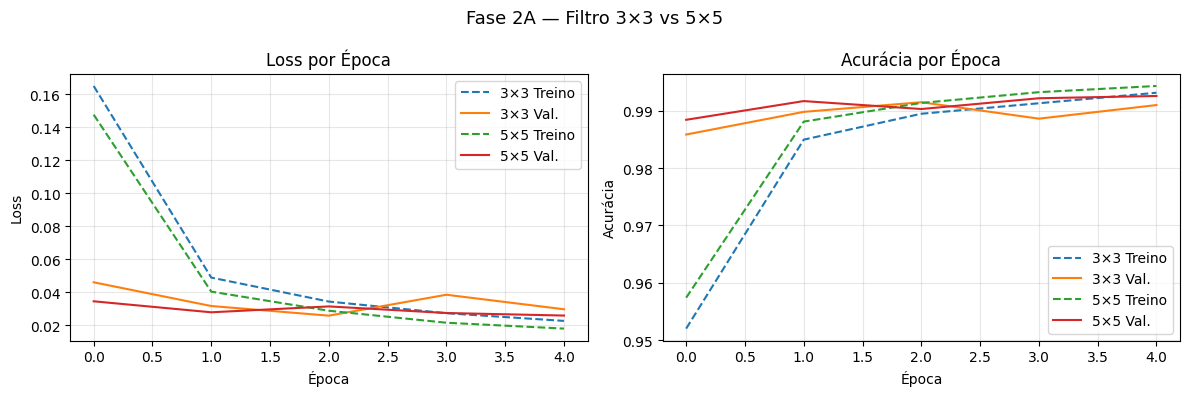

In [ ]:
# Comparação visual: 3x3 vs 5x5
def plot_comparison(histories, labels, title='Comparação de Arquiteturas'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for h, label in zip(histories, labels):
        axes[0].plot(h['train_loss'], linestyle='--', label=f'{label} Treino')
        axes[0].plot(h['val_loss'],   linestyle='-',  label=f'{label} Val.')
        axes[1].plot(h['train_acc'],  linestyle='--', label=f'{label} Treino')
        axes[1].plot(h['val_acc'],    linestyle='-',  label=f'{label} Val.')

    axes[0].set_title('Loss por Época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Acurácia por Época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_comparison(
    [history_baseline, history_5x5],
    ['3×3', '5×5'],
    title='Fase 2A — Filtro 3×3 vs 5×5'
)

##Criação de Rede com AVGPOOL no lugar de MAXPOOL

Usaremos a média da região no pool ao invés do maior valor



In [ ]:
class BaselineAvgPool(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, (3, 3))
        self.conv2 = nn.Conv2d(32, 32, (3, 3))
        self.activation = nn.ReLU()
        self.bnorm1 = nn.BatchNorm2d(32)
        self.bnorm2 = nn.BatchNorm2d(32)
        self.pool = nn.AvgPool2d((2, 2))
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(32 * 5 * 5, 128)
        self.linear2 = nn.Linear(128, 128)
        self.output  = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, X):
        X = self.pool(self.bnorm1(self.activation(self.conv1(X))))
        X = self.pool(self.bnorm2(self.activation(self.conv2(X))))
        X = self.flatten(X)
        X = self.dropout(self.activation(self.linear1(X)))
        X = self.dropout(self.activation(self.linear2(X)))
        return self.output(X)


=== AVG POOL ===
Época  1/5 | Loss Treino: 0.1626 | Acc Treino: 0.9532 | Loss Val: 0.0415 | Acc Val: 0.9862
Época  2/5 | Loss Treino: 0.0476 | Acc Treino: 0.9854 | Loss Val: 0.0381 | Acc Val: 0.9882
Época  3/5 | Loss Treino: 0.0352 | Acc Treino: 0.9893 | Loss Val: 0.0293 | Acc Val: 0.9911
Época  4/5 | Loss Treino: 0.0284 | Acc Treino: 0.9915 | Loss Val: 0.0321 | Acc Val: 0.9897
Época  5/5 | Loss Treino: 0.0245 | Acc Treino: 0.9926 | Loss Val: 0.0203 | Acc Val: 0.9935


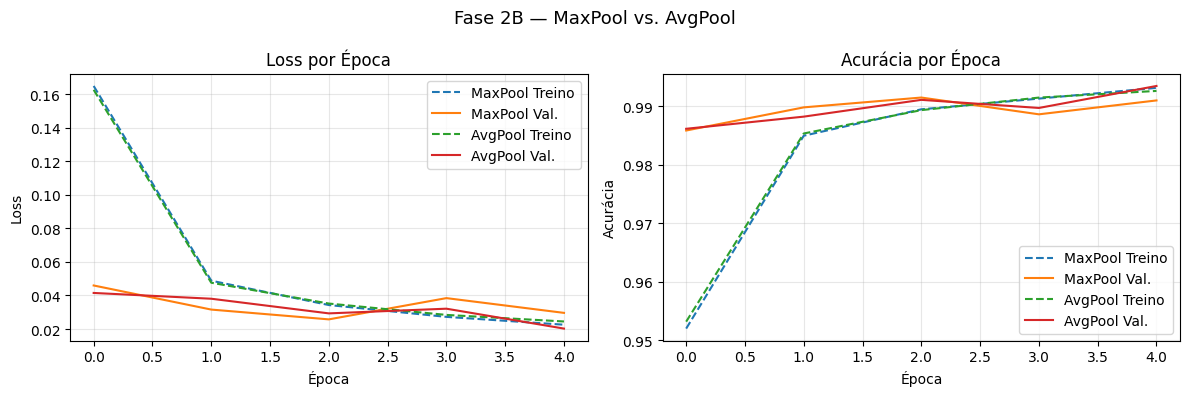

In [ ]:
print('=== AVG POOL ===')
net_avg = BaselineAvgPool()
history_avg = train_model(net_avg, train_loader, test_loader, epochs=5)

plot_comparison(
    [history_baseline, history_avg],
    ['MaxPool', 'AvgPool'],
    title='Fase 2B — MaxPool vs. AvgPool'
)

In [ ]:


class TresCamadas(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  32, (3, 3))
        self.conv2 = nn.Conv2d(32, 64, (3, 3))
        self.conv3 = nn.Conv2d(64, 64, (3, 3))
        self.activation = nn.ReLU()
        self.bnorm1 = nn.BatchNorm2d(32)
        self.bnorm2 = nn.BatchNorm2d(64)
        self.bnorm3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d((2, 2))
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(64 * 3 * 3, 128)
        self.linear2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, X):
        X = self.pool(self.bnorm1(self.activation(self.conv1(X))))
        X = self.pool(self.bnorm2(self.activation(self.conv2(X))))
        X = self.bnorm3(self.activation(self.conv3(X)))
        X = self.flatten(X)
        X = self.dropout(self.activation(self.linear1(X)))
        return self.linear2(X)


=== 3 CAMADAS CONVOLUCIONAIS ===
Época  1/5 | Loss Treino: 0.1222 | Acc Treino: 0.9657 | Loss Val: 0.0363 | Acc Val: 0.9884
Época  2/5 | Loss Treino: 0.0390 | Acc Treino: 0.9884 | Loss Val: 0.0340 | Acc Val: 0.9900
Época  3/5 | Loss Treino: 0.0274 | Acc Treino: 0.9911 | Loss Val: 0.0346 | Acc Val: 0.9884
Época  4/5 | Loss Treino: 0.0205 | Acc Treino: 0.9935 | Loss Val: 0.0272 | Acc Val: 0.9914
Época  5/5 | Loss Treino: 0.0158 | Acc Treino: 0.9951 | Loss Val: 0.0433 | Acc Val: 0.9887


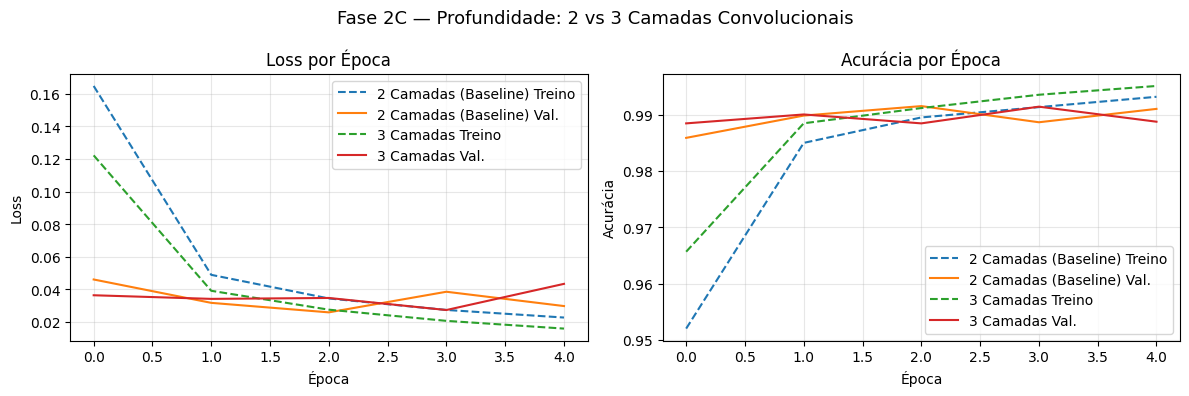

In [ ]:
print('=== 3 CAMADAS CONVOLUCIONAIS ===')
net_3cam = TresCamadas()
history_3cam = train_model(net_3cam, train_loader, test_loader, epochs=5)

plot_comparison(
    [history_baseline, history_3cam],
    ['2 Camadas (Baseline)', '3 Camadas'],
    title='Fase 2C — Profundidade: 2 vs 3 Camadas Convolucionais'
)

In [ ]:
batch_histories = {}

for batch_size in [32, 128, 1024]:
    print(f'\n=== BATCH SIZE: {batch_size} ===')
    torch.manual_seed(123)
    loader_tr = DataLoader(train, batch_size=batch_size, shuffle=True)
    loader_te = DataLoader(test,  batch_size=batch_size)
    net_b = Baseline3x3()
    h = train_model(net_b, loader_tr, loader_te, epochs=5)
    batch_histories[batch_size] = h


=== BATCH SIZE: 32 ===
Época  1/5 | Loss Treino: 0.1263 | Acc Treino: 0.9624 | Loss Val: 0.0470 | Acc Val: 0.9857
Época  2/5 | Loss Treino: 0.0552 | Acc Treino: 0.9840 | Loss Val: 0.0364 | Acc Val: 0.9886
Época  3/5 | Loss Treino: 0.0410 | Acc Treino: 0.9878 | Loss Val: 0.0308 | Acc Val: 0.9910
Época  4/5 | Loss Treino: 0.0329 | Acc Treino: 0.9903 | Loss Val: 0.0416 | Acc Val: 0.9900
Época  5/5 | Loss Treino: 0.0297 | Acc Treino: 0.9911 | Loss Val: 0.0274 | Acc Val: 0.9920

=== BATCH SIZE: 128 ===
Época  1/5 | Loss Treino: 0.1642 | Acc Treino: 0.9516 | Loss Val: 0.0430 | Acc Val: 0.9860
Época  2/5 | Loss Treino: 0.0491 | Acc Treino: 0.9857 | Loss Val: 0.0317 | Acc Val: 0.9898
Época  3/5 | Loss Treino: 0.0348 | Acc Treino: 0.9894 | Loss Val: 0.0274 | Acc Val: 0.9911
Época  4/5 | Loss Treino: 0.0283 | Acc Treino: 0.9912 | Loss Val: 0.0365 | Acc Val: 0.9888
Época  5/5 | Loss Treino: 0.0216 | Acc Treino: 0.9932 | Loss Val: 0.0304 | Acc Val: 0.9915

=== BATCH SIZE: 1024 ===
Época  1/5 | Lo

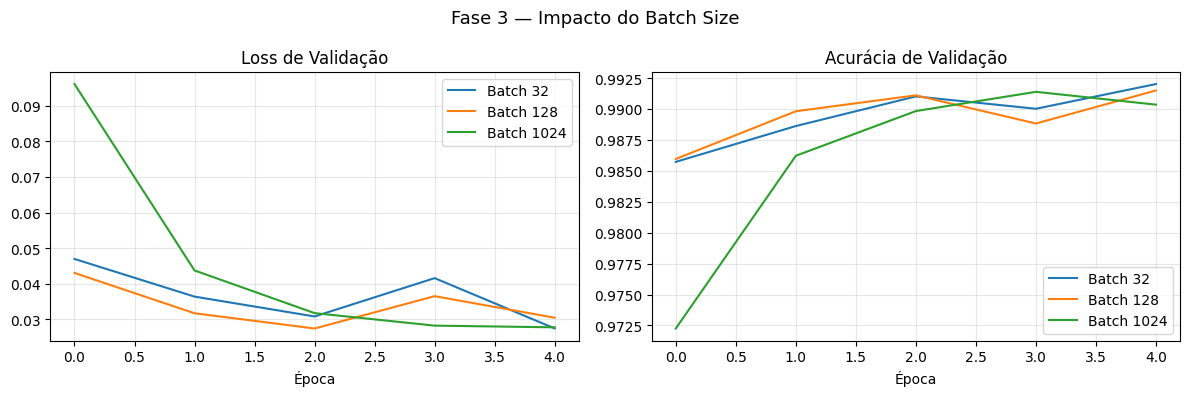

In [ ]:
# Comparar as 3 curvas de loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cores = {32: 'tab:blue', 128: 'tab:orange', 1024: 'tab:green'}

for bs, h in batch_histories.items():
    axes[0].plot(h['val_loss'], label=f'Batch {bs}', color=cores[bs])
    axes[1].plot(h['val_acc'],  label=f'Batch {bs}', color=cores[bs])

axes[0].set_title('Loss de Validação')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Acurácia de Validação')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fase 3 — Impacto do Batch Size', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def train_with_lr(net, train_loader, test_loader, lr, epochs=5):
    net.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        net.train()
        running_loss = 0.
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        net.eval()
        val_loss = 0.
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                val_loss += criterion(net(inputs), labels).item()

        history['train_loss'].append(running_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(test_loader))
        print(f'LR {lr:.0e} | Época {epoch+1} | Loss Treino: {history["train_loss"][-1]:.4f} | Loss Val: {history["val_loss"][-1]:.4f}')

    return history

lr_histories = {}
for lr in [0.1, 0.001, 0.00001]:
    print(f'\n=== LEARNING RATE: {lr} ===')
    torch.manual_seed(123)
    lr_histories[lr] = train_with_lr(Baseline3x3(), train_loader, test_loader, lr)


=== LEARNING RATE: 0.1 ===
LR 1e-01 | Época 1 | Loss Treino: 2.6901 | Loss Val: 2.3086
LR 1e-01 | Época 2 | Loss Treino: 2.3071 | Loss Val: 2.3071
LR 1e-01 | Época 3 | Loss Treino: 2.3069 | Loss Val: 2.3069
LR 1e-01 | Época 4 | Loss Treino: 2.3069 | Loss Val: 2.3078
LR 1e-01 | Época 5 | Loss Treino: 2.3070 | Loss Val: 2.3026

=== LEARNING RATE: 0.001 ===
LR 1e-03 | Época 1 | Loss Treino: 0.1652 | Loss Val: 0.0446
LR 1e-03 | Época 2 | Loss Treino: 0.0488 | Loss Val: 0.0298
LR 1e-03 | Época 3 | Loss Treino: 0.0351 | Loss Val: 0.0271
LR 1e-03 | Época 4 | Loss Treino: 0.0262 | Loss Val: 0.0328
LR 1e-03 | Época 5 | Loss Treino: 0.0224 | Loss Val: 0.0265

=== LEARNING RATE: 1e-05 ===
LR 1e-05 | Época 1 | Loss Treino: 2.0231 | Loss Val: 1.5309
LR 1e-05 | Época 2 | Loss Treino: 1.1712 | Loss Val: 0.6798
LR 1e-05 | Época 3 | Loss Treino: 0.6333 | Loss Val: 0.3719
LR 1e-05 | Época 4 | Loss Treino: 0.4214 | Loss Val: 0.2512
LR 1e-05 | Época 5 | Loss Treino: 0.3193 | Loss Val: 0.1910


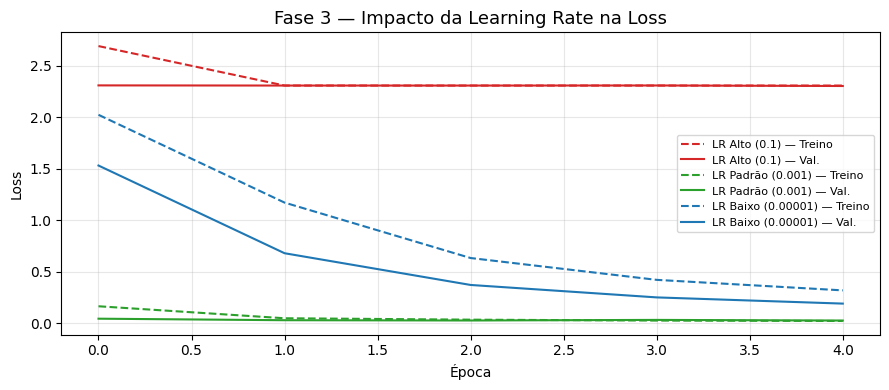

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
estilos = {0.1: ('tab:red', 'LR Alto (0.1)'), 0.001: ('tab:green', 'LR Padrão (0.001)'), 0.00001: ('tab:blue', 'LR Baixo (0.00001)')}

for lr, h in lr_histories.items():
    cor, label = estilos[lr]
    ax.plot(h['train_loss'], linestyle='--', color=cor, label=f'{label} — Treino')
    ax.plot(h['val_loss'],   linestyle='-',  color=cor, label=f'{label} — Val.')

ax.set_title('Fase 3 — Impacto da Learning Rate na Loss', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== BASELINE — 10 épocas (para análise de overfitting) ===
Época  1/10 | Loss Treino: 0.1649 | Acc Treino: 0.9517 | Loss Val: 0.0468 | Acc Val: 0.9848
Época  2/10 | Loss Treino: 0.0483 | Acc Treino: 0.9859 | Loss Val: 0.0320 | Acc Val: 0.9902
Época  3/10 | Loss Treino: 0.0341 | Acc Treino: 0.9894 | Loss Val: 0.0269 | Acc Val: 0.9917
Época  4/10 | Loss Treino: 0.0277 | Acc Treino: 0.9910 | Loss Val: 0.0343 | Acc Val: 0.9898
Época  5/10 | Loss Treino: 0.0226 | Acc Treino: 0.9928 | Loss Val: 0.0237 | Acc Val: 0.9929
Época  6/10 | Loss Treino: 0.0182 | Acc Treino: 0.9940 | Loss Val: 0.0361 | Acc Val: 0.9901
Época  7/10 | Loss Treino: 0.0171 | Acc Treino: 0.9948 | Loss Val: 0.0322 | Acc Val: 0.9896
Época  8/10 | Loss Treino: 0.0132 | Acc Treino: 0.9957 | Loss Val: 0.0287 | Acc Val: 0.9926
Época  9/10 | Loss Treino: 0.0144 | Acc Treino: 0.9956 | Loss Val: 0.0325 | Acc Val: 0.9919
Época 10/10 | Loss Treino: 0.0148 | Acc Treino: 0.9952 | Loss Val: 0.0379 | Acc Val: 0.9906


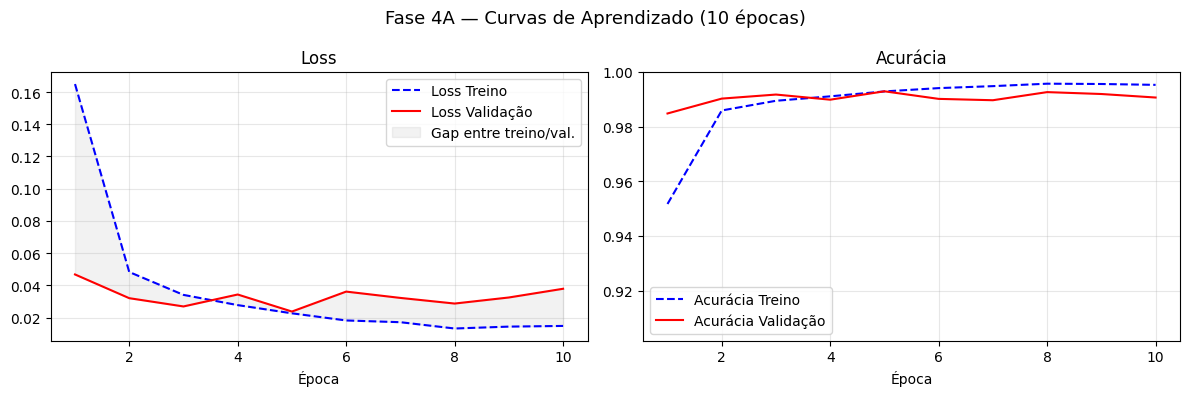

In [ ]:
def plot_learning_curves(history, titulo='Curvas de Aprendizado'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epocas = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epocas, history['train_loss'], 'b--', label='Loss Treino')
    axes[0].plot(epocas, history['val_loss'],   'r-',  label='Loss Validação')
    # "Gap" sem rótulo de diagnóstico — o fill apenas destaca a diferença entre as curvas.
    # Se val_loss > train_loss de forma crescente = overfitting.
    # Se val_loss < train_loss = comportamento normal (BN em eval vs train).
    axes[0].fill_between(epocas, history['train_loss'], history['val_loss'],
                         alpha=0.1, color='gray', label='Gap entre treino/val.')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epocas, history['train_acc'], 'b--', label='Acurácia Treino')
    axes[1].plot(epocas, history['val_acc'],   'r-',  label='Acurácia Validação')
    axes[1].set_title('Acurácia')
    axes[1].set_xlabel('Época')
    # ylim dinâmico: parte do min observado com folga, até 1.0
    min_acc = min(min(history['train_acc']), min(history['val_acc']))
    axes[1].set_ylim([max(0.0, min_acc - 0.05), 1.0])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

    gap = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]


# Treinar por mais épocas para ver comportamento de overfitting
print('=== BASELINE — 10 épocas (para análise de overfitting) ===')
torch.manual_seed(123)
net_10ep = Baseline3x3()
history_10ep = train_model(net_10ep, train_loader, test_loader, epochs=10)
plot_learning_curves(history_10ep, 'Fase 4A — Curvas de Aprendizado (10 épocas)')


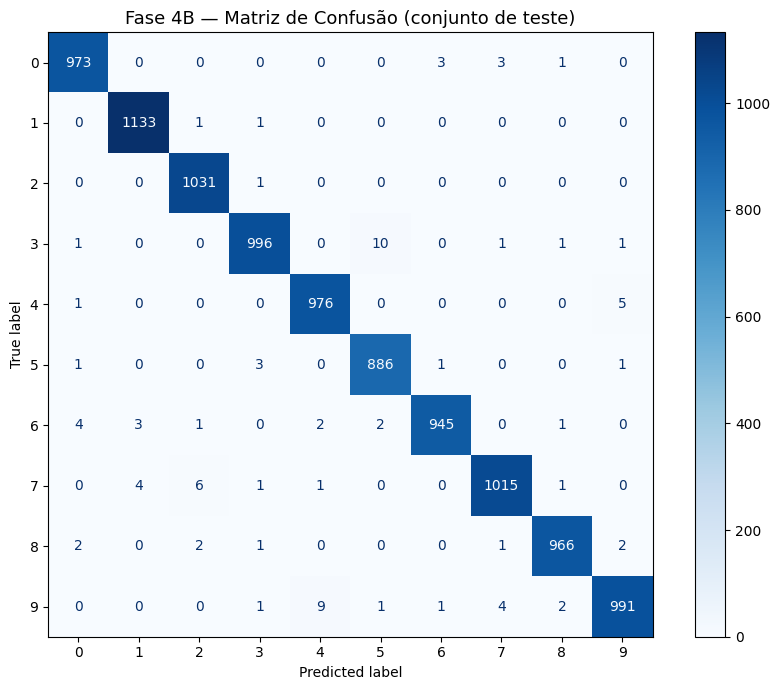


Top 3 confusões:
  Real: 3  →  Previsto: 5  (10 erros)
  Real: 9  →  Previsto: 4  (9 erros)
  Real: 7  →  Previsto: 2  (6 erros)


In [ ]:
def gerar_matriz_confusao(net, loader):
    net.eval()
    todos_labels = []
    todas_preds  = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = net(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            todas_preds.extend(preds)
            todos_labels.extend(labels.numpy())

    cm = confusion_matrix(todos_labels, todas_preds)

    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title('Fase 4B — Matriz de Confusão (conjunto de teste)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Top-3 confusões fora da diagonal
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    top3 = np.dstack(np.unravel_index(np.argsort(cm_off, axis=None)[-3:][::-1], cm_off.shape))[0]
    print('\nTop 3 confusões:')
    for real, pred in top3:
        print(f'  Real: {real}  →  Previsto: {pred}  ({cm_off[real, pred]} erros)')

    return cm

cm = gerar_matriz_confusao(net_10ep, test_loader)

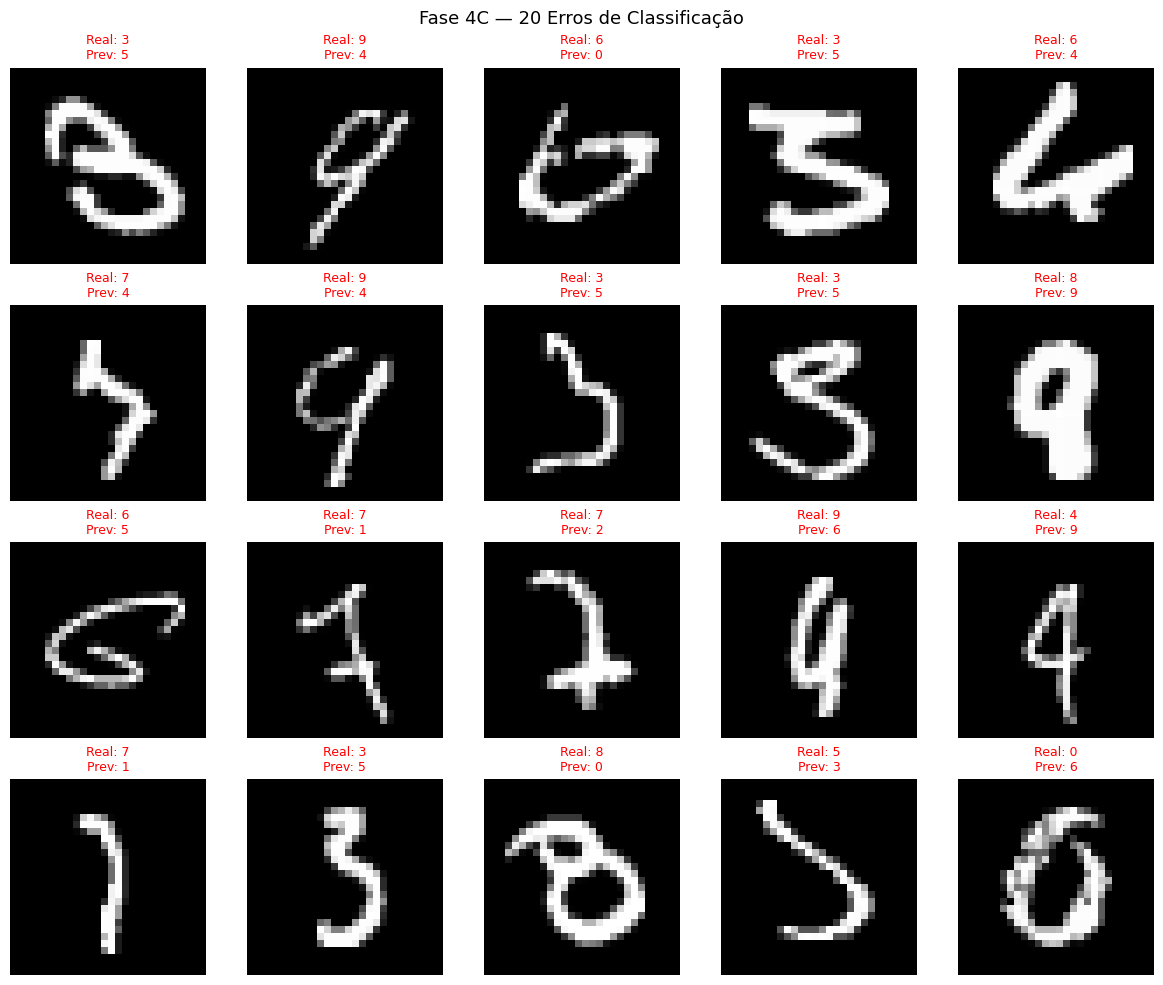

Total de erros exibidos: 20


In [ ]:
def analisar_erros(net, loader, n_erros=20):
    net.eval()
    imagens_erradas = []
    labels_errados  = []
    preds_erradas   = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs_dev = inputs.to(device)
            outputs = net(inputs_dev)
            preds = outputs.argmax(dim=1).cpu()

            mascara = preds != labels
            if mascara.any():
                imagens_erradas.append(inputs[mascara])
                labels_errados.append(labels[mascara])
                preds_erradas.append(preds[mascara])

            if sum(len(x) for x in imagens_erradas) >= n_erros:
                break

    if not imagens_erradas:
        print('Nenhum erro encontrado no loader fornecido.')
        return

    imagens_erradas = torch.cat(imagens_erradas)[:n_erros]
    labels_errados  = torch.cat(labels_errados)[:n_erros]
    preds_erradas   = torch.cat(preds_erradas)[:n_erros]

    # Ajusta o grid ao número real de erros disponíveis
    n_real = len(imagens_erradas)
    cols = 5
    rows = max(1, (n_real + cols - 1) // cols)  # teto da divisão

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 2.5))
    axes_flat = np.array(axes).flatten()

    for i in range(len(axes_flat)):
        ax = axes_flat[i]
        if i < n_real:
            ax.imshow(imagens_erradas[i].squeeze(), cmap='gray')
            ax.set_title(
                f'Real: {labels_errados[i].item()}\nPrev: {preds_erradas[i].item()}',
                color='red', fontsize=9
            )
        ax.axis('off')

    plt.suptitle(f'Fase 4C — {n_real} Erros de Classificação', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Total de erros exibidos: {n_real}')

analisar_erros(net_10ep, test_loader, n_erros=20)


In [ ]:
# Tabela de resumo automático com os modelos treinados neste notebook
resultados = {
    'Baseline 3×3 (MaxPool)': history_baseline,
    'Filtro 5×5':              history_5x5,
    'AvgPool':                 history_avg,
    '3 Camadas Conv':          history_3cam,
}

print(f'{"Modelo":<30} {"Acc Treino":>12} {"Acc Val":>10} {"Loss Val":>10}')
print('-' * 64)
for nome, h in resultados.items():
    print(f'{nome:<30} {h["train_acc"][-1]:>12.4f} {h["val_acc"][-1]:>10.4f} {h["val_loss"][-1]:>10.4f}')

Modelo                           Acc Treino    Acc Val   Loss Val
----------------------------------------------------------------
Baseline 3×3 (MaxPool)               0.9931     0.9910     0.0296
Filtro 5×5                           0.9943     0.9926     0.0258
AvgPool                              0.9926     0.9935     0.0203
3 Camadas Conv                       0.9951     0.9887     0.0433
